# Nyquist–Shannon Sampling with Tokyo Weather

## Dataset

Source: Meteostat Hourly API

Location: Tokyo Station area (≈ 35.6812, 139.7671) — timezone Asia/Tokyo

Cadence: Hourly (uniform sampling)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from meteostat import Point, Hourly


plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

### Data

In [4]:
# Tokyo Station vicinity
tokyo = Point(35.6812, 139.7671)
start = datetime(2024, 1, 1)
end = datetime(2024, 3, 31)


# 1) Fetch WITHOUT tz argument
df = Hourly(tokyo, start, end).fetch()


# 2) Make sure the index is in Asia/Tokyo
# - If tz-aware, convert to Asia/Tokyo.
# - If tz-naive, assume UTC (Meteostat default) then convert.
if df.index.tz is None:
    df = df.tz_localize('UTC').tz_convert('Asia/Tokyo')
else:
    df = df.tz_convert('Asia/Tokyo')


# 3) Keep common fields if present
cols = [c for c in ['temp','wspd','pres'] if c in df.columns]
if cols:
    df = df[cols]


# 4) Deduplicate any accidental duplicates
df = df[~df.index.duplicated(keep='first')]


print(df.index.tz) # should show Asia/Tokyo
print(df.head())

Asia/Tokyo
                           temp  wspd    pres
time                                         
2024-01-01 09:00:00+09:00   9.7  20.5  1018.6
2024-01-01 10:00:00+09:00  10.6  29.5  1019.3
2024-01-01 11:00:00+09:00  11.5  20.5  1019.2
2024-01-01 12:00:00+09:00  11.6  18.4  1019.2
2024-01-01 13:00:00+09:00  11.8  20.5  1019.6


## Day 1

In [5]:
def estimate_bandwidth(signal: pd.Series, fs_per_hour: float = 1.0, energy_quantile: float = 0.95):
    x = signal.dropna().values
    x = x - np.mean(x)
    N = len(x)
    if N < 16:
        raise ValueError('Need >= 16 samples for spectrum.')
    X = np.fft.rfft(x)
    P = (np.abs(X) ** 2) / N
    f = np.fft.rfftfreq(N, d=1.0/fs_per_hour) # cycles/hour
    c = np.cumsum(P); c = c / c[-1]
    idx = np.searchsorted(c, energy_quantile)
    B = f[min(idx, len(f)-1)]
    return float(B), f, P

In [6]:
sig_name = 'temp' if 'temp' in df.columns else ('wspd' if 'wspd' in df.columns else df.columns[0])
sig = df[sig_name]
fs = 1.0 # hourly sampling -> 1 sample/hour
B, f, P = estimate_bandwidth(sig, fs_per_hour=fs, energy_quantile=0.95)
nyquist_rate = 2 * B
nyquist_freq = B
print(f"Signal: {sig_name}")
print(f"Estimated B: {B:.4f} cycles/hour")
print(f"Nyquist frequency f_N: {nyquist_freq:.4f} cycles/hour")
print(f"Nyquist rate >= 2B: {nyquist_rate:.4f} samples/hour")

Signal: temp
Estimated B: 0.0764 cycles/hour
Nyquist frequency f_N: 0.0764 cycles/hour
Nyquist rate >= 2B: 0.1527 samples/hour


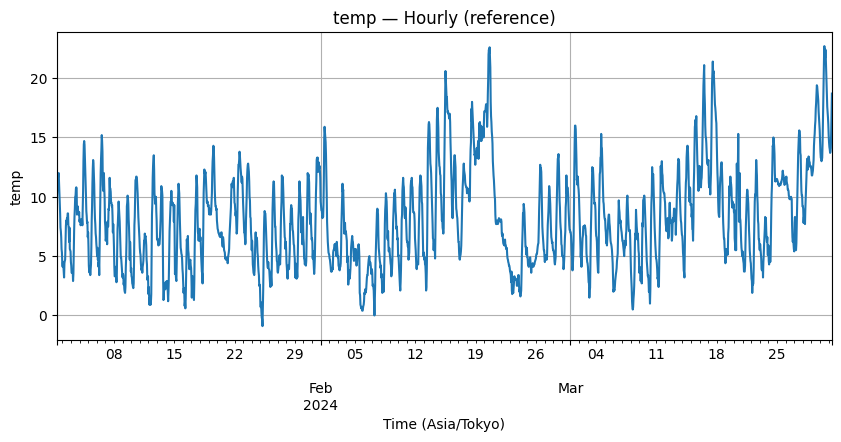

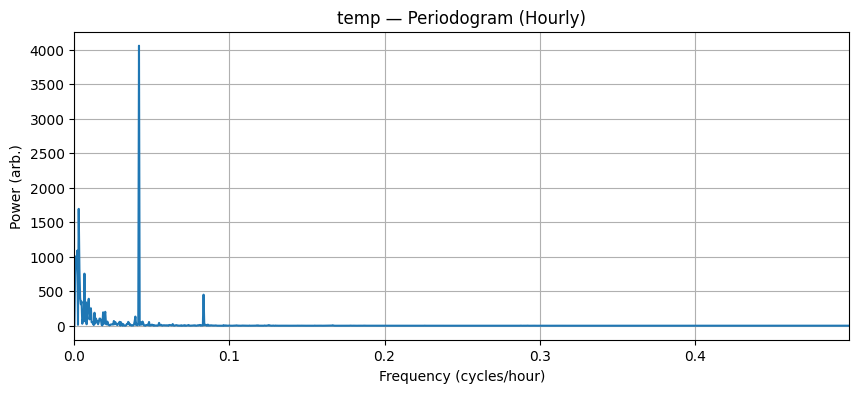

In [7]:
# Baseline hourly series
ax = sig.plot(); ax.set_title(f"{sig_name} — Hourly (reference)")
ax.set_xlabel("Time (Asia/Tokyo)"); ax.set_ylabel(sig_name)
plt.show()


# Periodogram (one‑sided)
fig, ax = plt.subplots()
ax.plot(f, P)
ax.set_xlim(0, f.max())
ax.set_xlabel("Frequency (cycles/hour)"); ax.set_ylabel("Power (arb.)")
ax.set_title(f"{sig_name} — Periodogram (Hourly)")
plt.show()